# Catalog and Reviews EDA

## Objective
Inspect the cleaned catalog and review parquet files generated by `00_data_acquisition.ipynb` to determine which features are truly useful for recommendations and conversational grounding. The previous notebook converted raw Amazon metadata and reviews into compact parquet files, establishing them as the project's standard inputs. This notebook carefully analyzes those inputs to guide which item attributes will support content retrieval, assesses the availability of review text for grounded explanations, and sets minimum evidence thresholds for the next stage.

## Inputs
- `../data/items.parquet`
- `../data/reviews.parquet`

## Outputs
- validated schemas for both parquet files
- catalog coverage and metadata completeness tables
- review coverage, rating, helpful-vote, and image summaries
- text-readiness and evidence-coverage metrics for future RAG grounding
- recommendation-oriented constraints for the next stage

In [1]:
import os
import sys
from functools import partial
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-crs")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT_CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
for candidate in PROJECT_ROOT_CANDIDATES:
    if (candidate / "functions").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the project root containing functions/.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from functions.io import safe_preview as shared_safe_preview, scalar as shared_scalar, sql as shared_sql

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

DATA_DIR_CANDIDATES = [Path("../data").resolve(), Path("data").resolve()]
for candidate in DATA_DIR_CANDIDATES:
    if (candidate / "items.parquet").exists() and (candidate / "reviews.parquet").exists():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError("Could not find items.parquet and reviews.parquet in ../data or data.")

ITEMS_PATH = DATA_DIR / "items.parquet"
REVIEWS_PATH = DATA_DIR / "reviews.parquet"
TMP_DIR = DATA_DIR / "duckdb_tmp"
TMP_DIR.mkdir(parents=True, exist_ok=True)

MAX_PANDAS_ROWS = 50_000

con = duckdb.connect()
con.execute("PRAGMA threads=4")
con.execute("PRAGMA preserve_insertion_order=false")
con.execute(f"PRAGMA temp_directory='{TMP_DIR.as_posix()}'")
con.execute("PRAGMA memory_limit='8GB'")

con.execute(f"CREATE OR REPLACE VIEW items AS SELECT * FROM read_parquet('{ITEMS_PATH.as_posix()}')")
con.execute(f"CREATE OR REPLACE VIEW reviews AS SELECT * FROM read_parquet('{REVIEWS_PATH.as_posix()}')")

sql = partial(shared_sql, con)
scalar = partial(shared_scalar, con)
safe_preview = partial(shared_safe_preview, con, max_rows=MAX_PANDAS_ROWS)

In [2]:
access_summary = pd.DataFrame(
    [
        {
            "dataset": "items",
            "path": str(ITEMS_PATH),
            "size_gib": round(ITEMS_PATH.stat().st_size / (1024**3), 2),
            "safe_access_pattern": "DuckDB view + SQL aggregates; pandas only for small result tables",
        },
        {
            "dataset": "reviews",
            "path": str(REVIEWS_PATH),
            "size_gib": round(REVIEWS_PATH.stat().st_size / (1024**3), 2),
            "safe_access_pattern": "DuckDB view + SQL aggregates; never materialize the full parquet in pandas",
        },
    ]
)

display(access_summary)
display(safe_preview("items", 3))
display(safe_preview("reviews", 3))

,dataset,path,size_gib,safe_access_pattern
0,items,/home/imont/GroundedRecommender/data/items.parquet,1.52,DuckDB view + SQL aggregates; pandas only for small result tables
1,reviews,/home/imont/GroundedRecommender/data/reviews.parquet,12.62,DuckDB view + SQL aggregates; never materialize the full parquet in pandas


,parent_asin,main_category,title,store,source,average_rating,rating_number,price,categories_path,description_text,features_text,n_images,n_videos,n_bought_together,has_images,has_videos,has_bought_together,has_description,has_features
0,0547337876,Books,Five Little Monkeys Play Hide and Seek (A Five Little Monkeys Story),Eileen Christelow (Author),electronics,4.8,534,7.99,"[""Electronics"",""Home Audio"",""Home Theater""]","[""Review"",""\""popular series...counting practice.... offers children the pleasure of finding the monkeys...energetic...colorful....giddy, good-hearted fun.\"" BOOKLIST Booklist, ALA\""The energetic i...","[""Mama’s out dancing, and Lulu, the babysitter, is in charge. The Five Little Monkeys are supposed to go to bed, but they convince Lulu there’s time for just one game of hide-and-seek first . . . ...",5,0,0,True,False,False,True,True
1,0746066929,Amazon Home,That's Not My Bunny,Usborne Publishing Ltd,home_and_kitchen,4.8,2910,19.45,[],"[""Lots of baby bunnies! This brightly coloured board book holds enormous appeal for both babies and adults. The very young will love the chance to feel a furry ear, tickle a paw or touch a cottont...",[],4,0,0,True,False,False,True,False
2,0756064384,Office Products,27 Amendments Skinny Poster,Teacher's Discovery,home_and_kitchen,4.4,23,NaN,"[""Home & Kitchen"",""Wall Art"",""Posters & Prints""]","[""Display all 27 amendments to the U.S. Constitution, including the Bill of Rights!"",""13 x 38 inches. Laminated.""]",[],12,0,0,True,False,False,True,False


,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,source,n_images,has_images
0,5.0,Excellent Product,"This worked great for my 75+ year old parents to consolidate some very old remotes. The ability to override the button resets and learn from the original, working IR remote was very useful for an...",B08L5XVL3J,B09Y55WW5P,AHFXWDGXCEETA4LQET64RPNAR7KA,1642737773362,0,True,electronics,0,False
1,5.0,Great for vertical monitor mounting,"This worked great to mount a 20"" monitor vertically.",B089CXBGQF,B089CXBGQF,AHFXWDGXCEETA4LQET64RPNAR7KA,1626305318076,0,True,electronics,0,False
2,5.0,Adapter works great with USB Power Delivery and Lightning,"When I needed to connect my YubiKey 5C NFC (male) to my iPad Pro (Lightning) to access Google Advanced Protection, I could only get a USB-A with the Apple adapter. I had a USB-A to C (male) chargi...",B07S292X2V,B0BTB6ZH39,AHFXWDGXCEETA4LQET64RPNAR7KA,1626305220549,2,True,electronics,0,False


## Schema Inspection

Start with schema validation before deciding what to analyze. This avoids inventing unavailable fields and keeps the rest of the notebook tied to the columns actually produced by `00_data_acquisition.ipynb`.
    

In [3]:
items_schema = sql("DESCRIBE SELECT * FROM items")
reviews_schema = sql("DESCRIBE SELECT * FROM reviews")

display(items_schema)
display(reviews_schema)

,column_name,column_type,null,key,default,extra
0,parent_asin,VARCHAR,YES,None,None,None
1,main_category,VARCHAR,YES,None,None,None
2,title,VARCHAR,YES,None,None,None
3,store,VARCHAR,YES,None,None,None
4,source,VARCHAR,YES,None,None,None
5,average_rating,DOUBLE,YES,None,None,None
6,rating_number,BIGINT,YES,None,None,None
7,price,DOUBLE,YES,None,None,None
8,categories_path,VARCHAR,YES,None,None,None
9,description_text,VARCHAR,YES,None,None,None


,column_name,column_type,null,key,default,extra
0,rating,DOUBLE,YES,None,None,None
1,title,VARCHAR,YES,None,None,None
2,text,VARCHAR,YES,None,None,None
3,asin,VARCHAR,YES,None,None,None
4,parent_asin,VARCHAR,YES,None,None,None
5,user_id,VARCHAR,YES,None,None,None
6,timestamp,BIGINT,YES,None,None,None
7,helpful_vote,BIGINT,YES,None,None,None
8,verified_purchase,BOOLEAN,YES,None,None,None
9,source,VARCHAR,YES,None,None,None


In [4]:
column_roles = pd.DataFrame(
    [
        {
            "dataset": "items",
            "column": "parent_asin",
            "project_role": "join key",
            "why_it_matters": "Stable product identifier for joining catalog rows with review evidence.",
        },
        {
            "dataset": "items",
            "column": "title",
            "project_role": "item representation",
            "why_it_matters": "Primary short-form product text for content retrieval and candidate presentation.",
        },
        {
            "dataset": "items",
            "column": "main_category",
            "project_role": "catalog segmentation",
            "why_it_matters": "High-level domain signal for evaluation splits and domain-aware analysis.",
        },
        {
            "dataset": "items",
            "column": "categories_path",
            "project_role": "structured metadata",
            "why_it_matters": "Useful for hierarchical constraints and lightweight taxonomy features.",
        },
        {
            "dataset": "items",
            "column": "description_text",
            "project_role": "grounding text",
            "why_it_matters": "Longer product-side evidence for explanations and retrieval enrichment.",
        },
        {
            "dataset": "items",
            "column": "features_text",
            "project_role": "grounding text",
            "why_it_matters": "Bullet-style metadata that often maps cleanly to explanation snippets.",
        },
        {
            "dataset": "items",
            "column": "average_rating / rating_number",
            "project_role": "ranking priors",
            "why_it_matters": "Useful popularity and quality priors for retrieval and reranking baselines.",
        },
        {
            "dataset": "items",
            "column": "price",
            "project_role": "structured filtering",
            "why_it_matters": "Supports explicit user constraints such as budget or price bands.",
        },
        {
            "dataset": "reviews",
            "column": "rating",
            "project_role": "feedback signal",
            "why_it_matters": "Core supervision signal for preference modeling and sentiment summaries.",
        },
        {
            "dataset": "reviews",
            "column": "title / text",
            "project_role": "grounding evidence",
            "why_it_matters": "Main textual evidence for RAG-backed conversational explanations.",
        },
        {
            "dataset": "reviews",
            "column": "helpful_vote",
            "project_role": "confidence feature",
            "why_it_matters": "Potential soft quality signal for weighting reviews in explanations.",
        },
        {
            "dataset": "reviews",
            "column": "verified_purchase",
            "project_role": "confidence feature",
            "why_it_matters": "Potential trust signal when choosing evidence for grounded responses.",
        },
        {
            "dataset": "reviews",
            "column": "n_images / has_images",
            "project_role": "evidence enrichment",
            "why_it_matters": "Useful for multimodal follow-up later, or at least for understanding richer reviews.",
        },
        {
            "dataset": "reviews",
            "column": "parent_asin",
            "project_role": "join key",
            "why_it_matters": "Connects review evidence back to the catalog item representation.",
        },
        {
            "dataset": "reviews",
            "column": "source",
            "project_role": "domain analysis",
            "why_it_matters": "Supports source-aware evaluation and cross-domain comparisons.",
        },
    ]
)

display(column_roles)

,dataset,column,project_role,why_it_matters
0,items,parent_asin,join key,Stable product identifier for joining catalog rows with review evidence.
1,items,title,item representation,Primary short-form product text for content retrieval and candidate presentation.
2,items,main_category,catalog segmentation,High-level domain signal for evaluation splits and domain-aware analysis.
3,items,categories_path,structured metadata,Useful for hierarchical constraints and lightweight taxonomy features.
4,items,description_text,grounding text,Longer product-side evidence for explanations and retrieval enrichment.
5,items,features_text,grounding text,Bullet-style metadata that often maps cleanly to explanation snippets.
6,items,average_rating / rating_number,ranking priors,Useful popularity and quality priors for retrieval and reranking baselines.
7,items,price,structured filtering,Supports explicit user constraints such as budget or price bands.
8,reviews,rating,feedback signal,Core supervision signal for preference modeling and sentiment summaries.
9,reviews,title / text,grounding evidence,Main textual evidence for RAG-backed conversational explanations.


## Catalog Overview

The catalog-side EDA focuses on scale, category structure, price coverage, and metadata completeness. These fields matter directly for candidate generation and for how much product-side grounding text is available before touching the reviews.
    

,item_count,source_count,main_category_count,items_with_price,pct_items_with_price
0,3767130,3,46,1491950,39.6


,source,items,pct_items
0,home_and_kitchen,2058011,54.63
1,electronics,875592,23.24
2,sports_and_outdoors,833527,22.13


,main_category,items,pct_items
0,Amazon Home,1696454,45.03
1,Sports & Outdoors,495531,13.15
2,NaN,285238,7.57
3,All Electronics,231691,6.15
4,Computers,227640,6.04
5,AMAZON FASHION,158037,4.20
6,Tools & Home Improvement,142500,3.78
7,Camera & Photo,116395,3.09
8,Cell Phones & Accessories,89140,2.37
9,Home Audio & Theater,57784,1.53


,priced_items,min_price,median_price,p90_price,max_price
0,1491938,0.01,20.99,112.8,99999.0


,source,items,pct_with_description,pct_with_features,pct_with_price
0,home_and_kitchen,2058011,51.72,80.79,40.57
1,electronics,875592,53.98,79.25,38.33
2,sports_and_outdoors,833527,61.37,88.25,38.57


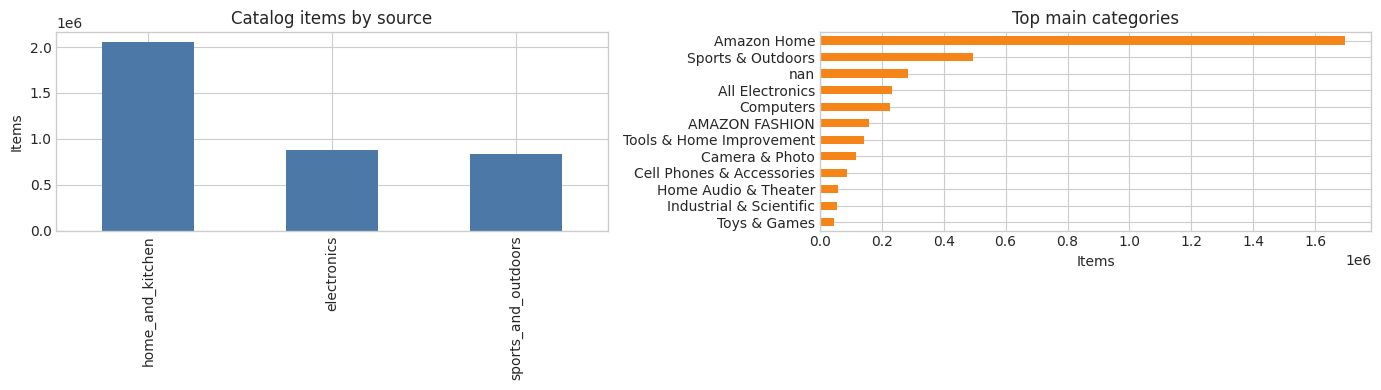

In [5]:
catalog_headline = sql(
    """
    SELECT
        COUNT(*) AS item_count,
        COUNT(DISTINCT source) AS source_count,
        COUNT(DISTINCT main_category) AS main_category_count,
        COUNT(*) FILTER (WHERE price IS NOT NULL) AS items_with_price,
        ROUND(100.0 * COUNT(*) FILTER (WHERE price IS NOT NULL) / COUNT(*), 2) AS pct_items_with_price
    FROM items
    """
)

catalog_by_source = sql(
    """
    SELECT
        source,
        COUNT(*) AS items,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_items
    FROM items
    GROUP BY source
    ORDER BY items DESC
    """
)

main_category_distribution = sql(
    """
    SELECT
        main_category,
        COUNT(*) AS items,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_items
    FROM items
    GROUP BY main_category
    ORDER BY items DESC
    LIMIT 12
    """
)

price_stats = sql(
    """
    SELECT
        COUNT(*) AS priced_items,
        ROUND(MIN(price), 2) AS min_price,
        ROUND(quantile_cont(price, 0.5), 2) AS median_price,
        ROUND(quantile_cont(price, 0.9), 2) AS p90_price,
        ROUND(MAX(price), 2) AS max_price
    FROM items
    WHERE price IS NOT NULL AND price > 0
    """
)

metadata_by_source = sql(
    """
    SELECT
        source,
        COUNT(*) AS items,
        ROUND(100.0 * COUNT(*) FILTER (WHERE has_description) / COUNT(*), 2) AS pct_with_description,
        ROUND(100.0 * COUNT(*) FILTER (WHERE has_features) / COUNT(*), 2) AS pct_with_features,
        ROUND(100.0 * COUNT(*) FILTER (WHERE price IS NOT NULL) / COUNT(*), 2) AS pct_with_price
    FROM items
    GROUP BY source
    ORDER BY items DESC
    """
)

display(catalog_headline)
display(catalog_by_source)
display(main_category_distribution)
display(price_stats)
display(metadata_by_source)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
catalog_by_source.plot.bar(x="source", y="items", ax=axes[0], color="#4c78a8", legend=False)
axes[0].set_title("Catalog items by source")
axes[0].set_xlabel("")
axes[0].set_ylabel("Items")

main_category_distribution.sort_values("items").plot.barh(
    x="main_category", y="items", ax=axes[1], color="#f58518", legend=False
)
axes[1].set_title("Top main categories")
axes[1].set_xlabel("Items")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,field,available_items,availability_pct
0,has_images,3766797,99.99
1,title,3766933,99.99
2,store,3740479,99.29
3,categories_path,3493310,92.73
4,features_text,3092096,82.08
5,description_text,2048717,54.38
6,price,1491950,39.60
7,has_videos,1436539,38.13
8,has_bought_together,0,0.00


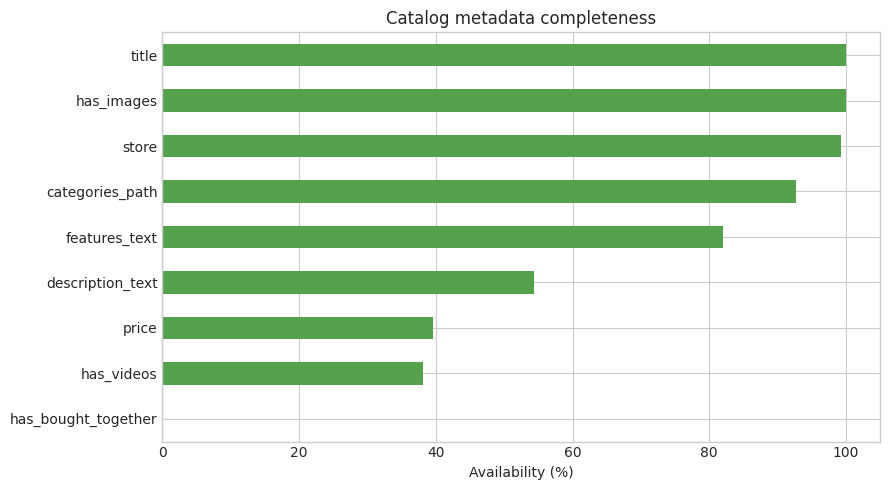

In [6]:
item_completeness = sql(
    """
    WITH stats AS (
        SELECT
            COUNT(*) AS total_items,
            COUNT(*) FILTER (WHERE title IS NOT NULL AND trim(title) <> '') AS title_available,
            COUNT(*) FILTER (WHERE store IS NOT NULL AND trim(store) <> '') AS store_available,
            COUNT(*) FILTER (WHERE categories_path IS NOT NULL AND trim(categories_path) NOT IN ('', '[]')) AS categories_path_available,
            COUNT(*) FILTER (WHERE description_text IS NOT NULL AND trim(description_text) NOT IN ('', '[]')) AS description_text_available,
            COUNT(*) FILTER (WHERE features_text IS NOT NULL AND trim(features_text) NOT IN ('', '[]')) AS features_text_available,
            COUNT(*) FILTER (WHERE price IS NOT NULL) AS price_available,
            COUNT(*) FILTER (WHERE has_images) AS image_available,
            COUNT(*) FILTER (WHERE has_videos) AS video_available,
            COUNT(*) FILTER (WHERE has_bought_together) AS bought_together_available
        FROM items
    )
    SELECT field, available_items, ROUND(100.0 * available_items / total_items, 2) AS availability_pct
    FROM (
        SELECT total_items, 'title' AS field, title_available AS available_items FROM stats
        UNION ALL
        SELECT total_items, 'store' AS field, store_available AS available_items FROM stats
        UNION ALL
        SELECT total_items, 'categories_path' AS field, categories_path_available AS available_items FROM stats
        UNION ALL
        SELECT total_items, 'description_text' AS field, description_text_available AS available_items FROM stats
        UNION ALL
        SELECT total_items, 'features_text' AS field, features_text_available AS available_items FROM stats
        UNION ALL
        SELECT total_items, 'price' AS field, price_available AS available_items FROM stats
        UNION ALL
        SELECT total_items, 'has_images' AS field, image_available AS available_items FROM stats
        UNION ALL
        SELECT total_items, 'has_videos' AS field, video_available AS available_items FROM stats
        UNION ALL
        SELECT total_items, 'has_bought_together' AS field, bought_together_available AS available_items FROM stats
    )
    ORDER BY availability_pct DESC, field
    """
)

display(item_completeness)

fig, ax = plt.subplots(figsize=(9, 5))
item_completeness.sort_values("availability_pct").plot.barh(
    x="field", y="availability_pct", ax=ax, color="#54a24b", legend=False
)
ax.set_title("Catalog metadata completeness")
ax.set_xlabel("Availability (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Reviews Overview

The review-side EDA focuses on rating balance, verification, helpfulness, image usage, and text coverage. These are the main inputs for future explanation quality, review weighting, and evidence selection.
    

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,review_count,avg_rating,median_rating
0,125397903,4.162,5.0


,rating,review_count,pct_reviews
0,0.0,2,0.00
1,1.0,13635622,10.87
2,2.0,6290083,5.02
3,3.0,8380157,6.68
4,4.0,14930510,11.91
5,5.0,82161529,65.52


,source,review_count,pct_reviews
0,home_and_kitchen,64526793,51.46
1,electronics,42527070,33.91
2,sports_and_outdoors,18344040,14.63


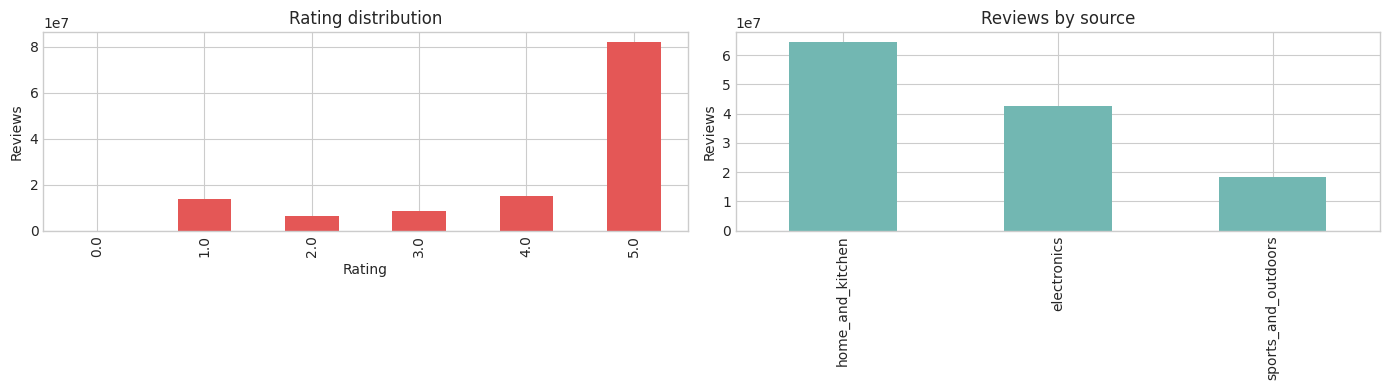

In [7]:
reviews_headline = sql(
    """
    SELECT
        COUNT(*) AS review_count,
        ROUND(AVG(rating), 3) AS avg_rating,
        ROUND(quantile_cont(rating, 0.5), 2) AS median_rating
    FROM reviews
    """
)

rating_distribution = sql(
    """
    SELECT
        rating,
        COUNT(*) AS review_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_reviews
    FROM reviews
    GROUP BY rating
    ORDER BY rating
    """
)

reviews_by_source = sql(
    """
    SELECT
        source,
        COUNT(*) AS review_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_reviews
    FROM reviews
    GROUP BY source
    ORDER BY review_count DESC
    """
)

display(reviews_headline)
display(rating_distribution)
display(reviews_by_source)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rating_distribution.plot.bar(x="rating", y="review_count", ax=axes[0], color="#e45756", legend=False)
axes[0].set_title("Rating distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Reviews")

reviews_by_source.plot.bar(x="source", y="review_count", ax=axes[1], color="#72b7b2", legend=False)
axes[1].set_title("Reviews by source")
axes[1].set_xlabel("")
axes[1].set_ylabel("Reviews")

plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_reviews,verified_purchase_reviews,pct_verified_purchase,helpful_vote_nonzero_reviews,pct_helpful_vote_nonzero,reviews_with_images,pct_reviews_with_images,reviews_with_title,pct_reviews_with_title,reviews_with_text,pct_reviews_with_text
0,125397903,116753518,93.11,28476694,22.71,8390527,6.69,125397900,100.0,125206290,99.85


,helpful_vote_bucket,review_count,pct_reviews
0,0,96921193,77.29
1,1-2,20084611,16.02
2,3-5,4584359,3.66
3,6-10,1899193,1.51
4,11-20,1033009,0.82
5,21+,875538,0.70


,image_bucket,review_count,pct_reviews
0,0,117007376,93.31
1,1,5169389,4.12
2,2,1822603,1.45
3,3,758463,0.60
4,4+,640072,0.51


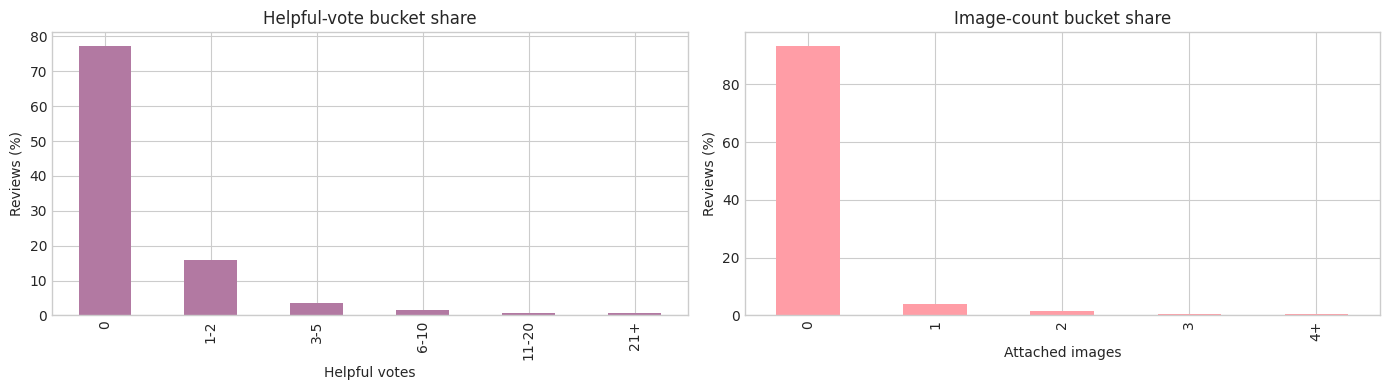

In [8]:
review_quality_signals = sql(
    """
    WITH cleaned AS (
        SELECT
            COALESCE(helpful_vote, 0) AS helpful_vote,
            COALESCE(verified_purchase, FALSE) AS verified_purchase,
            COALESCE(has_images, FALSE) AS has_images,
            COALESCE(n_images, 0) AS n_images,
            CASE WHEN title IS NULL THEN '' ELSE trim(title) END AS clean_title,
            CASE WHEN text IS NULL THEN '' ELSE trim(regexp_replace(text, '<[^>]+>', ' ', 'g')) END AS clean_text
        FROM reviews
    )
    SELECT
        COUNT(*) AS total_reviews,
        COUNT(*) FILTER (WHERE verified_purchase) AS verified_purchase_reviews,
        ROUND(100.0 * COUNT(*) FILTER (WHERE verified_purchase) / COUNT(*), 2) AS pct_verified_purchase,
        COUNT(*) FILTER (WHERE helpful_vote > 0) AS helpful_vote_nonzero_reviews,
        ROUND(100.0 * COUNT(*) FILTER (WHERE helpful_vote > 0) / COUNT(*), 2) AS pct_helpful_vote_nonzero,
        COUNT(*) FILTER (WHERE has_images) AS reviews_with_images,
        ROUND(100.0 * COUNT(*) FILTER (WHERE has_images) / COUNT(*), 2) AS pct_reviews_with_images,
        COUNT(*) FILTER (WHERE clean_title <> '') AS reviews_with_title,
        ROUND(100.0 * COUNT(*) FILTER (WHERE clean_title <> '') / COUNT(*), 2) AS pct_reviews_with_title,
        COUNT(*) FILTER (WHERE clean_text <> '' AND clean_text <> '[]') AS reviews_with_text,
        ROUND(100.0 * COUNT(*) FILTER (WHERE clean_text <> '' AND clean_text <> '[]') / COUNT(*), 2) AS pct_reviews_with_text
    FROM cleaned
    """
)

helpful_vote_buckets = sql(
    """
    WITH binned AS (
        SELECT
            CASE
                WHEN COALESCE(helpful_vote, 0) = 0 THEN '0'
                WHEN helpful_vote BETWEEN 1 AND 2 THEN '1-2'
                WHEN helpful_vote BETWEEN 3 AND 5 THEN '3-5'
                WHEN helpful_vote BETWEEN 6 AND 10 THEN '6-10'
                WHEN helpful_vote BETWEEN 11 AND 20 THEN '11-20'
                ELSE '21+'
            END AS helpful_vote_bucket,
            CASE
                WHEN COALESCE(helpful_vote, 0) = 0 THEN 0
                WHEN helpful_vote BETWEEN 1 AND 2 THEN 1
                WHEN helpful_vote BETWEEN 3 AND 5 THEN 2
                WHEN helpful_vote BETWEEN 6 AND 10 THEN 3
                WHEN helpful_vote BETWEEN 11 AND 20 THEN 4
                ELSE 5
            END AS bucket_order
        FROM reviews
    )
    SELECT
        helpful_vote_bucket,
        COUNT(*) AS review_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_reviews
    FROM binned
    GROUP BY helpful_vote_bucket, bucket_order
    ORDER BY bucket_order
    """
)

review_image_buckets = sql(
    """
    WITH binned AS (
        SELECT
            CASE
                WHEN COALESCE(n_images, 0) = 0 THEN '0'
                WHEN n_images = 1 THEN '1'
                WHEN n_images = 2 THEN '2'
                WHEN n_images = 3 THEN '3'
                ELSE '4+'
            END AS image_bucket,
            CASE
                WHEN COALESCE(n_images, 0) = 0 THEN 0
                WHEN n_images = 1 THEN 1
                WHEN n_images = 2 THEN 2
                WHEN n_images = 3 THEN 3
                ELSE 4
            END AS bucket_order
        FROM reviews
    )
    SELECT
        image_bucket,
        COUNT(*) AS review_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_reviews
    FROM binned
    GROUP BY image_bucket, bucket_order
    ORDER BY bucket_order
    """
)

display(review_quality_signals)
display(helpful_vote_buckets)
display(review_image_buckets)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
helpful_vote_buckets.plot.bar(
    x="helpful_vote_bucket", y="pct_reviews", ax=axes[0], color="#b279a2", legend=False
)
axes[0].set_title("Helpful-vote bucket share")
axes[0].set_xlabel("Helpful votes")
axes[0].set_ylabel("Reviews (%)")

review_image_buckets.plot.bar(x="image_bucket", y="pct_reviews", ax=axes[1], color="#ff9da6", legend=False)
axes[1].set_title("Image-count bucket share")
axes[1].set_xlabel("Attached images")
axes[1].set_ylabel("Reviews (%)")

plt.tight_layout()
plt.show()

## Text and Grounding Readiness

A conversational recommender only benefits from RAG if there is enough usable text to cite. Here the focus is review text coverage, title and text completeness, and the amount of reasonably substantial evidence available for future grounded explanations.
    

In [9]:
text_readiness = sql(
    """
    WITH cleaned AS (
        SELECT
            source,
            CASE WHEN title IS NULL THEN '' ELSE trim(title) END AS clean_title,
            CASE WHEN text IS NULL THEN '' ELSE trim(regexp_replace(text, '<[^>]+>', ' ', 'g')) END AS clean_text
        FROM reviews
    )
    SELECT
        COUNT(*) AS total_reviews,
        COUNT(*) FILTER (WHERE clean_title <> '' AND clean_text <> '' AND clean_text <> '[]') AS reviews_with_title_and_text,
        ROUND(100.0 * COUNT(*) FILTER (WHERE clean_title <> '' AND clean_text <> '' AND clean_text <> '[]') / COUNT(*), 2) AS pct_reviews_with_title_and_text,
        ROUND(AVG(length(clean_text)), 1) AS avg_text_chars,
        ROUND(quantile_cont(length(clean_text), 0.5), 1) AS median_text_chars,
        ROUND(quantile_cont(length(clean_text), 0.9), 1) AS p90_text_chars,
        ROUND(quantile_cont(length(clean_text), 0.99), 1) AS p99_text_chars,
        COUNT(*) FILTER (WHERE length(clean_text) >= 50) AS reviews_ge_50_chars,
        ROUND(100.0 * COUNT(*) FILTER (WHERE length(clean_text) >= 50) / COUNT(*), 2) AS pct_reviews_ge_50_chars,
        COUNT(*) FILTER (WHERE length(clean_text) >= 200) AS reviews_ge_200_chars,
        ROUND(100.0 * COUNT(*) FILTER (WHERE length(clean_text) >= 200) / COUNT(*), 2) AS pct_reviews_ge_200_chars,
        COUNT(*) FILTER (WHERE length(clean_text) >= 500) AS reviews_ge_500_chars,
        ROUND(100.0 * COUNT(*) FILTER (WHERE length(clean_text) >= 500) / COUNT(*), 2) AS pct_reviews_ge_500_chars
    FROM cleaned
    """
)

text_readiness_by_source = sql(
    """
    WITH cleaned AS (
        SELECT
            source,
            CASE WHEN text IS NULL THEN '' ELSE trim(regexp_replace(text, '<[^>]+>', ' ', 'g')) END AS clean_text
        FROM reviews
    )
    SELECT
        source,
        COUNT(*) AS reviews,
        ROUND(100.0 * COUNT(*) FILTER (WHERE clean_text <> '' AND clean_text <> '[]') / COUNT(*), 2) AS pct_with_text,
        ROUND(quantile_cont(length(clean_text), 0.5), 1) AS median_text_chars,
        ROUND(100.0 * COUNT(*) FILTER (WHERE length(clean_text) >= 200) / COUNT(*), 2) AS pct_ge_200_chars
    FROM cleaned
    GROUP BY source
    ORDER BY reviews DESC
    """
)

display(text_readiness)
display(text_readiness_by_source)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_reviews,reviews_with_title_and_text,pct_reviews_with_title_and_text,avg_text_chars,median_text_chars,p90_text_chars,p99_text_chars,reviews_ge_50_chars,pct_reviews_ge_50_chars,reviews_ge_200_chars,pct_reviews_ge_200_chars,reviews_ge_500_chars,pct_reviews_ge_500_chars
0,125397903,125206287,99.85,200.6,112.0,448.0,1433.0,92421293,73.7,37551546,29.95,10470198,8.35


,source,reviews,pct_with_text,median_text_chars,pct_ge_200_chars
0,home_and_kitchen,64526793,99.79,106.0,27.56
1,electronics,42527070,99.91,121.0,33.64
2,sports_and_outdoors,18344040,99.91,111.0,29.76


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,text_length_bucket,review_count,pct_reviews
0,0,191613,0.15
1,1-49,32784997,26.14
2,50-199,54869747,43.76
3,200-499,27081348,21.60
4,500-999,7700274,6.14
5,1000+,2769924,2.21


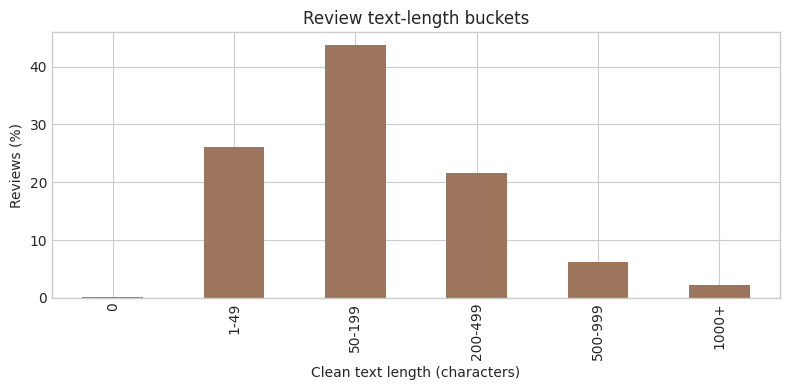

In [10]:
text_length_buckets = sql(
    """
    WITH cleaned AS (
        SELECT
            CASE WHEN text IS NULL THEN '' ELSE trim(regexp_replace(text, '<[^>]+>', ' ', 'g')) END AS clean_text
        FROM reviews
    ),
    binned AS (
        SELECT
            CASE
                WHEN clean_text = '' OR clean_text = '[]' THEN '0'
                WHEN length(clean_text) < 50 THEN '1-49'
                WHEN length(clean_text) < 200 THEN '50-199'
                WHEN length(clean_text) < 500 THEN '200-499'
                WHEN length(clean_text) < 1000 THEN '500-999'
                ELSE '1000+'
            END AS text_length_bucket,
            CASE
                WHEN clean_text = '' OR clean_text = '[]' THEN 0
                WHEN length(clean_text) < 50 THEN 1
                WHEN length(clean_text) < 200 THEN 2
                WHEN length(clean_text) < 500 THEN 3
                WHEN length(clean_text) < 1000 THEN 4
                ELSE 5
            END AS bucket_order
        FROM cleaned
    )
    SELECT
        text_length_bucket,
        COUNT(*) AS review_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_reviews
    FROM binned
    GROUP BY text_length_bucket, bucket_order
    ORDER BY bucket_order
    """
)

display(text_length_buckets)

fig, ax = plt.subplots(figsize=(8, 4))
text_length_buckets.plot.bar(x="text_length_bucket", y="pct_reviews", ax=ax, color="#9d755d", legend=False)
ax.set_title("Review text-length buckets")
ax.set_xlabel("Clean text length (characters)")
ax.set_ylabel("Reviews (%)")
plt.tight_layout()
plt.show()

## Recommendation-Oriented Constraints

This section translates the raw EDA into design constraints for the recommender. The main questions are whether the catalog has enough metadata for content-based retrieval, whether item-level review coverage is dense enough for similarity and explanation work, and how strict the future evidence thresholds should be.
    

In [11]:
item_review_coverage = sql(
    """
    WITH review_evidence AS (
        SELECT
            parent_asin,
            COUNT(*) AS review_rows,
            COUNT(*) FILTER (
                WHERE text IS NOT NULL
                  AND trim(regexp_replace(text, '<[^>]+>', ' ', 'g')) NOT IN ('', '[]')
            ) AS textual_reviews,
            COUNT(*) FILTER (
                WHERE text IS NOT NULL
                  AND length(trim(regexp_replace(text, '<[^>]+>', ' ', 'g'))) >= 200
            ) AS substantial_reviews
        FROM reviews
        GROUP BY parent_asin
    )
    SELECT
        COUNT(*) AS catalog_items,
        COUNT(*) FILTER (WHERE COALESCE(r.review_rows, 0) > 0) AS items_with_any_review,
        ROUND(100.0 * COUNT(*) FILTER (WHERE COALESCE(r.review_rows, 0) > 0) / COUNT(*), 2) AS pct_items_with_any_review,
        ROUND(quantile_cont(COALESCE(r.review_rows, 0), 0.5), 1) AS median_reviews_per_item,
        ROUND(quantile_cont(COALESCE(r.review_rows, 0), 0.9), 1) AS p90_reviews_per_item,
        ROUND(quantile_cont(COALESCE(r.review_rows, 0), 0.99), 1) AS p99_reviews_per_item,
        COUNT(*) FILTER (WHERE COALESCE(r.textual_reviews, 0) >= 3) AS items_with_3plus_textual_reviews,
        ROUND(100.0 * COUNT(*) FILTER (WHERE COALESCE(r.textual_reviews, 0) >= 3) / COUNT(*), 2) AS pct_items_with_3plus_textual_reviews,
        COUNT(*) FILTER (WHERE COALESCE(r.substantial_reviews, 0) >= 3) AS items_with_3plus_substantial_reviews,
        ROUND(100.0 * COUNT(*) FILTER (WHERE COALESCE(r.substantial_reviews, 0) >= 3) / COUNT(*), 2) AS pct_items_with_3plus_substantial_reviews,
        COUNT(*) FILTER (WHERE COALESCE(r.substantial_reviews, 0) >= 10) AS items_with_10plus_substantial_reviews,
        ROUND(100.0 * COUNT(*) FILTER (WHERE COALESCE(r.substantial_reviews, 0) >= 10) / COUNT(*), 2) AS pct_items_with_10plus_substantial_reviews
    FROM items i
    LEFT JOIN review_evidence r USING (parent_asin)
    """
)

catalog_readiness = sql(
    """
    SELECT
        COUNT(*) AS total_items,
        COUNT(*) FILTER (
            WHERE title IS NOT NULL
              AND trim(title) <> ''
              AND categories_path IS NOT NULL
              AND trim(categories_path) NOT IN ('', '[]')
        ) AS items_with_title_and_category,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE title IS NOT NULL
                  AND trim(title) <> ''
                  AND categories_path IS NOT NULL
                  AND trim(categories_path) NOT IN ('', '[]')
            ) / COUNT(*),
            2
        ) AS pct_items_with_title_and_category,
        COUNT(*) FILTER (
            WHERE title IS NOT NULL
              AND trim(title) <> ''
              AND (
                  (description_text IS NOT NULL AND trim(description_text) NOT IN ('', '[]'))
                  OR (features_text IS NOT NULL AND trim(features_text) NOT IN ('', '[]'))
              )
        ) AS items_with_richer_metadata,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE title IS NOT NULL
                  AND trim(title) <> ''
                  AND (
                      (description_text IS NOT NULL AND trim(description_text) NOT IN ('', '[]'))
                      OR (features_text IS NOT NULL AND trim(features_text) NOT IN ('', '[]'))
                  )
            ) / COUNT(*),
            2
        ) AS pct_items_with_richer_metadata,
        COUNT(*) FILTER (
            WHERE price IS NOT NULL
              AND title IS NOT NULL
              AND trim(title) <> ''
              AND categories_path IS NOT NULL
              AND trim(categories_path) NOT IN ('', '[]')
        ) AS items_ready_for_structured_filtering,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE price IS NOT NULL
                  AND title IS NOT NULL
                  AND trim(title) <> ''
                  AND categories_path IS NOT NULL
                  AND trim(categories_path) NOT IN ('', '[]')
            ) / COUNT(*),
            2
        ) AS pct_items_ready_for_structured_filtering
    FROM items
    """
)

recommendation_readiness_by_source = sql(
    """
    WITH review_evidence AS (
        SELECT
            parent_asin,
            COUNT(*) AS review_rows,
            COUNT(*) FILTER (
                WHERE text IS NOT NULL
                  AND length(trim(regexp_replace(text, '<[^>]+>', ' ', 'g'))) >= 200
            ) AS substantial_reviews
        FROM reviews
        GROUP BY parent_asin
    )
    SELECT
        i.source,
        COUNT(*) AS items,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE i.title IS NOT NULL
                  AND trim(i.title) <> ''
                  AND (
                      (i.description_text IS NOT NULL AND trim(i.description_text) NOT IN ('', '[]'))
                      OR (i.features_text IS NOT NULL AND trim(i.features_text) NOT IN ('', '[]'))
                      OR (i.categories_path IS NOT NULL AND trim(i.categories_path) NOT IN ('', '[]'))
                  )
            ) / COUNT(*),
            2
        ) AS pct_content_ready,
        ROUND(quantile_cont(COALESCE(r.review_rows, 0), 0.5), 1) AS median_reviews_per_item,
        ROUND(
            100.0 * COUNT(*) FILTER (WHERE COALESCE(r.substantial_reviews, 0) >= 3) / COUNT(*),
            2
        ) AS pct_grounding_ready_3plus
    FROM items i
    LEFT JOIN review_evidence r USING (parent_asin)
    GROUP BY i.source
    ORDER BY items DESC
    """
)

display(item_review_coverage)
display(catalog_readiness)
display(recommendation_readiness_by_source)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,catalog_items,items_with_any_review,pct_items_with_any_review,median_reviews_per_item,p90_reviews_per_item,p99_reviews_per_item,items_with_3plus_textual_reviews,pct_items_with_3plus_textual_reviews,items_with_3plus_substantial_reviews,pct_items_with_3plus_substantial_reviews,items_with_10plus_substantial_reviews,pct_items_with_10plus_substantial_reviews
0,3767130,3766467,99.98,6.0,49.0,457.0,2736146,72.63,1394516,37.02,562431,14.93


,total_items,items_with_title_and_category,pct_items_with_title_and_category,items_with_richer_metadata,pct_items_with_richer_metadata,items_ready_for_structured_filtering,pct_items_ready_for_structured_filtering
0,3767130,3493133,92.73,3197818,84.89,1450641,38.51


,source,items,pct_content_ready,median_reviews_per_item,pct_grounding_ready_3plus
0,home_and_kitchen,2058011,93.67,6.0,34.03
1,electronics,875592,95.22,8.0,49.43
2,sports_and_outdoors,833527,96.89,5.0,31.37


## Key Findings

The final block turns the aggregate tables into short conclusions that summarize what matters most for the next stage.
    

In [12]:
catalog_items = int(catalog_headline.loc[0, "item_count"])
review_rows = int(reviews_headline.loc[0, "review_count"])
pct_price = float(catalog_headline.loc[0, "pct_items_with_price"])
pct_description = float(
    item_completeness.loc[item_completeness["field"] == "description_text", "availability_pct"].iloc[0]
)
pct_features = float(
    item_completeness.loc[item_completeness["field"] == "features_text", "availability_pct"].iloc[0]
)
pct_verified = float(review_quality_signals.loc[0, "pct_verified_purchase"])
pct_helpful_nonzero = float(review_quality_signals.loc[0, "pct_helpful_vote_nonzero"])
pct_reviews_with_text = float(review_quality_signals.loc[0, "pct_reviews_with_text"])
pct_reviews_ge_200 = float(text_readiness.loc[0, "pct_reviews_ge_200_chars"])
pct_items_with_richer_metadata = float(catalog_readiness.loc[0, "pct_items_with_richer_metadata"])
pct_items_ready_for_filtering = float(catalog_readiness.loc[0, "pct_items_ready_for_structured_filtering"])
pct_items_with_3plus_substantial = float(
    item_review_coverage.loc[0, "pct_items_with_3plus_substantial_reviews"]
)
pct_items_with_10plus_substantial = float(
    item_review_coverage.loc[0, "pct_items_with_10plus_substantial_reviews"]
)
median_reviews_per_item = float(item_review_coverage.loc[0, "median_reviews_per_item"])

findings = [
    f"- The working dataset is large enough to require a SQL-first workflow: **{catalog_items:,}** catalog items and **{review_rows:,}** review rows.",
    f"- Catalog-side structured filtering is feasible, but not universal: **{pct_price:.1f}%** of items have price and **{pct_items_ready_for_filtering:.1f}%** are ready for title + category + price filtering out of the box.",
    f"- Content-based retrieval is viable because **{pct_items_with_richer_metadata:.1f}%** of items have title plus richer descriptive text; description coverage (**{pct_description:.1f}%**) and feature coverage (**{pct_features:.1f}%**) should be treated as useful but non-mandatory signals.",
    f"- Review grounding is broadly available: **{pct_reviews_with_text:.1f}%** of reviews contain text, and **{pct_reviews_ge_200:.1f}%** are at least 200 characters long after light cleaning.",
    f"- Grounded explanations will still be uneven across the catalog. The median item has **{median_reviews_per_item:.1f}** reviews, **{pct_items_with_3plus_substantial:.1f}%** of items have at least 3 substantial reviews, and **{pct_items_with_10plus_substantial:.1f}%** reach 10 such reviews.",
    f"- Review trust signals should be soft features rather than hard gates: verified purchase is common (**{pct_verified:.1f}%**), but non-zero helpful votes are much rarer (**{pct_helpful_nonzero:.1f}%**).",
    "- The next notebook can define the join-safe analytical base for retrieval and ranking experiments: item text field selection, review evidence thresholds, and the first content and review features for candidate generation and grounded response support.",
]

display(Markdown("\n".join(findings)))

- The working dataset is large enough to require a SQL-first workflow: **3,767,130** catalog items and **125,397,903** review rows.
- Catalog-side structured filtering is feasible, but not universal: **39.6%** of items have price and **38.5%** are ready for title + category + price filtering out of the box.
- Content-based retrieval is viable because **84.9%** of items have title plus richer descriptive text; description coverage (**54.4%**) and feature coverage (**82.1%**) should be treated as useful but non-mandatory signals.
- Review grounding is broadly available: **99.8%** of reviews contain text, and **29.9%** are at least 200 characters long after light cleaning.
- Grounded explanations will still be uneven across the catalog. The median item has **6.0** reviews, **37.0%** of items have at least 3 substantial reviews, and **14.9%** reach 10 such reviews.
- Review trust signals should be soft features rather than hard gates: verified purchase is common (**93.1%**), but non-zero helpful votes are much rarer (**22.7%**).
- The next notebook can define the join-safe analytical base for retrieval and ranking experiments: item text field selection, review evidence thresholds, and the first content and review features for candidate generation and grounded response support.